# Spotify Song Clustering — From Raw Data to Production Playlists

A complete unsupervised machine learning project that turns 5,235 Spotify songs into musically coherent playlists, respecting the operational constraint of 50 to 250 songs per playlist.

## Project overview

**The brief:** Cluster a catalogue of Spotify songs into playlists, where each playlist must contain between 50 and 250 songs.

**The data:** 5,235 songs with 10 audio features from the Spotify Web API.

**The approach:** K-Means clustering with StandardScaler preprocessing, followed by a split-and-merge post-processing pipeline to achieve full size compliance.

## What this notebook covers

1. Exploration and outlier analysis
2. Scaling decision
3. Translating business constraints into a valid k range
4. Demonstrating that naive K-Means cannot satisfy the size brief
5. The split-and-merge algorithm
6. Feature selection experiment (10 vs 9 features)
7. Finding the optimal starting k
8. Per-cluster coherence analysis
9. **Handling the incoherent cluster — three approaches compared:**
   - **Approach A:** Keep everything (baseline)
   - **Approach B:** Drop the incoherent cluster
   - **Approach C:** Sub-cluster the incoherent songs into smaller groups
10. Cluster profiles and auto-naming
11. Final delivery export

## Final result

Three configurations delivered side-by-side. The recommended approach (sub-clustering, Approach C) keeps all 5,230 songs, eliminates the incoherent cluster, and produces 41 playlists — improving coherence without losing data.

---
## 1. Imports and setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

from sklearn import set_config
set_config(transform_output="pandas")

plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")
print("Setup complete")

Setup complete


---
## 2. Load and explore the data

In [2]:
df = pd.read_csv("3_spotify_5000_songs.csv")
df.columns = df.columns.str.strip()  # strip whitespace from headers

print(f"Dataset shape: {df.shape}")
print(f"Total songs: {len(df)}")
df.head(3)

Dataset shape: (5235, 19)
Total songs: 5235


,Unnamed: 0,name,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,type,duration_ms,time_signature,id,html
0,0,Se Eu Quiser Falar Com Deus ...,Gilberto Gil,0.658,0.259,11,-13.141,0,0.0705,0.694,0.000059,0.975,0.306,110.376,,256213,4,1n7JnwviZ7zf0LR1tcGFq7,https://open.spotify.com/track/1n7JnwviZ7zf0LR...
1,1,Saudade De Bahia ...,Antônio Carlos Jobim,0.742,0.399,2,-12.646,1,0.0346,0.217,0.000002,0.107,0.693,125.039,,191867,4,5QGM1U0eCYrQuwSJwTm5Zq,https://open.spotify.com/track/5QGM1U0eCYrQuwS...
2,2,"Canta Canta, Minha Gente ...",Martinho Da Vila,0.851,0.730,2,-11.048,1,0.3470,0.453,0.000063,0.124,0.905,93.698,,152267,4,0NLIFSZxPzQhCwnkn5PJYs,https://open.spotify.com/track/0NLIFSZxPzQhCwn...


In [3]:
all_audio_features = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence",
    "tempo", "duration_ms"
]
X_raw = df[all_audio_features].copy()
X_raw.describe().round(2)

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,5235.00,5235.00,5235.00,5235.00,5235.00,5235.00,5235.00,5235.00,5235.00,5235.00
mean,0.51,0.65,-9.34,0.08,0.29,0.26,0.19,0.44,118.72,247911.17
std,0.22,0.29,6.29,0.07,0.36,0.37,0.15,0.28,28.57,135633.02
min,0.00,0.00,-60.00,0.00,0.00,0.00,0.00,0.00,0.00,32760.00
25%,0.31,0.48,-11.34,0.04,0.00,0.00,0.09,0.20,96.17,189991.00
50%,0.54,0.74,-7.34,0.06,0.10,0.00,0.12,0.42,119.18,224667.00
75%,0.69,0.89,-5.26,0.10,0.57,0.64,0.24,0.68,134.02,271720.00
max,0.97,1.00,1.34,0.92,1.00,0.98,0.99,0.98,213.99,3815787.00


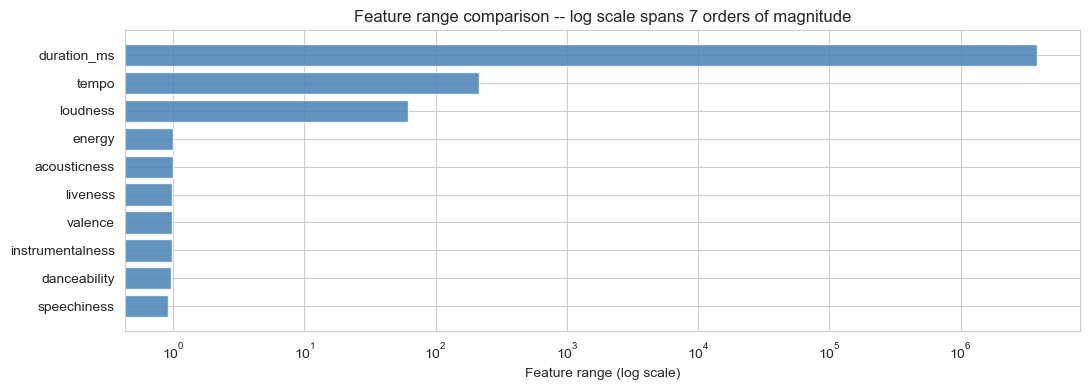

duration_ms range is 3,912,127x larger than danceability range.
Without scaling, K-Means distance would be dominated by duration_ms.


In [4]:
# Range visualisation — shows why scaling is mandatory
ranges = {col: X_raw[col].max() - X_raw[col].min() for col in all_audio_features}
ranges_sorted = dict(sorted(ranges.items(), key=lambda x: x[1]))

plt.figure(figsize=(11, 4))
plt.barh(list(ranges_sorted.keys()), list(ranges_sorted.values()), color="steelblue", alpha=0.85)
plt.xscale("log")
plt.xlabel("Feature range (log scale)")
plt.title("Feature range comparison -- log scale spans 7 orders of magnitude")
plt.tight_layout()
plt.show()

print(f"duration_ms range is {ranges['duration_ms']/ranges['danceability']:,.0f}x larger than danceability range.")
print("Without scaling, K-Means distance would be dominated by duration_ms.")

---
## 3. Outlier analysis: errors vs real signal

The critical question is not "how many outliers?" but "are they errors or real musical signal?

In [5]:
print(f"{'Feature':<20} {'Outliers':>10} {'% of dataset':>15}")
print("-" * 50)
for col in all_audio_features:
    q1, q3 = X_raw[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_outliers = ((X_raw[col] < q1 - 1.5*iqr) | (X_raw[col] > q3 + 1.5*iqr)).sum()
    print(f"{col:<20} {n_outliers:>10} {n_outliers/len(df)*100:>14.1f}%")

Feature                Outliers    % of dataset
--------------------------------------------------
danceability                  0            0.0%
energy                        0            0.0%
loudness                    355            6.8%
speechiness                 437            8.3%
acousticness                  0            0.0%
instrumentalness              0            0.0%
liveness                    295            5.6%
valence                       0            0.0%
tempo                        51            1.0%
duration_ms                 308            5.9%


In [6]:
# Inspect actual extreme songs -- are they errors or real?
print("LONGEST songs (duration outliers):")
for _, row in df.nlargest(5, "duration_ms")[["name", "artist", "duration_ms"]].iterrows():
    print(f"  {row['duration_ms']/60000:>5.1f} min  --  {str(row['name']).strip()[:40]:<42} -- {str(row['artist']).strip()[:25]}")

print("\nMost SPEECHY songs:")
for _, row in df.nlargest(5, "speechiness")[["name", "artist", "speechiness"]].iterrows():
    print(f"  {row['speechiness']:>6.3f}    --  {str(row['name']).strip()[:40]:<42} -- {str(row['artist']).strip()[:25]}")

LONGEST songs (duration outliers):
   63.6 min  --  dlp 1.1                                    -- William Basinski
   59.8 min  --  Symphony No. 6                             -- Allan Pettersson
   31.6 min  --  Symphony No. 3                             -- Polish National Radio Sym
   29.9 min  --  Essence                                    -- Laraaji
   26.9 min  --  Tod und Verklärung Op.24, TrV 158          -- Richard Strauss

Most SPEECHY songs:
   0.918    --  I'M DEAD                                   -- Duckwrth
   0.576    --  This Is Why I'm Hot                        -- MiMS
   0.518    --  Got It                                     -- Boys Noize
   0.516    --  Pegaito a la Pared (feat. Plan B) - Remi   -- Tego Calderon
   0.511    --  I'm Better (feat. Lamb)                    -- Missy Elliott


These are real songs (classical, rap, ambient) — not errors. We keep them.

Only **5 rows have impossible values** per Spotify's spec (tempo=0 or loudness>0). Those we drop.

In [7]:
errors_mask = (df["tempo"] == 0) | (df["loudness"] > 0)
print(f"Songs with impossible values: {errors_mask.sum()}")

df_clean = df[~errors_mask].copy().reset_index(drop=True)
print(f"Dataset after dropping errors: {len(df_clean)} songs")

Songs with impossible values: 5
Dataset after dropping errors: 5230 songs


---
## 4. Translating the brief into a valid k range

In [8]:
def calculate_k_range(n_songs, min_size=50, max_size=250):
    return int(np.ceil(n_songs / max_size)), int(np.floor(n_songs / min_size))

K_MIN, K_MAX = calculate_k_range(len(df_clean))
print(f"Valid k range: {K_MIN} to {K_MAX}")
print(f"At k={K_MIN}: average playlist size = {len(df_clean)/K_MIN:.0f}")
print(f"At k={K_MAX}: average playlist size = {len(df_clean)/K_MAX:.0f}")

Valid k range: 21 to 104
At k=21: average playlist size = 249
At k=104: average playlist size = 50


---
## 5. Naive K-Means cannot satisfy the size brief

Search the full valid k range with 10 features. No k value produces zero size violations.

In [9]:
X_scaled_10 = StandardScaler().fit_transform(df_clean[all_audio_features])
X_scaled_10_arr = X_scaled_10.values if hasattr(X_scaled_10, 'values') else np.asarray(X_scaled_10)

naive_results = []
for k in range(K_MIN, K_MAX + 1, 2):
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled_10_arr)
    sizes = pd.Series(labels).value_counts()
    naive_results.append({
        "k": k,
        "below_50": int((sizes < 50).sum()),
        "above_250": int((sizes > 250).sum()),
        "violations": int(((sizes < 50) | (sizes > 250)).sum())
    })

naive_df = pd.DataFrame(naive_results)
print(f"Minimum size violations across all naive k values: {naive_df['violations'].min()}")
print("No naive k satisfies the brief. Post-processing is required.")

Minimum size violations across all naive k values: 7
No naive k satisfies the brief. Post-processing is required.


---
## 6. The split-then-merge pipeline

A two-step post-processing algorithm that guarantees full size compliance:

- **Step A:** For any cluster over 250 songs, run K-Means(k=2) on those songs to split it. Repeat until none exceed 250.
- **Step B:** For any cluster under 50 songs, merge into the nearest neighbour with room. Re-split if needed.

In [10]:
def split_then_merge(X_scaled, starting_k, min_size=50, max_size=250, random_state=42):
    """Cluster, then split oversized, then merge undersized clusters."""
    km = KMeans(n_clusters=starting_k, init="k-means++", n_init=10, random_state=random_state)
    labels = km.fit_predict(X_scaled)
    
    # STEP A: recursive split
    next_id = int(labels.max()) + 1
    while True:
        sizes = pd.Series(labels).value_counts()
        oversized = sizes[sizes > max_size].index.tolist()
        if not oversized: break
        for cid in oversized:
            mask = labels == cid
            km_split = KMeans(n_clusters=2, init="k-means++", n_init=10, random_state=random_state)
            sub_labels = km_split.fit_predict(X_scaled[mask])
            labels[mask] = np.where(sub_labels == 0, cid, next_id)
            next_id += 1
    
    # STEP B: merge undersized
    iteration = 0
    while iteration < 50:
        iteration += 1
        sizes = pd.Series(labels).value_counts()
        undersized = sizes[sizes < min_size].index.tolist()
        if not undersized: break
        
        unique_ids = sorted(set(labels))
        centroids = {cid: X_scaled[labels == cid].mean(axis=0) for cid in unique_ids}
        sizes_sorted = sizes.sort_values()
        smallest_cid = int(sizes_sorted.index[0])
        smallest_size = int(sizes_sorted.iloc[0])
        
        best_cid, best_dist = None, float("inf")
        for other_cid in unique_ids:
            if other_cid == smallest_cid: continue
            if sizes[other_cid] + smallest_size > max_size: continue
            dist = np.linalg.norm(centroids[smallest_cid] - centroids[other_cid])
            if dist < best_dist:
                best_dist, best_cid = dist, other_cid
        
        if best_cid is None:
            for other_cid in unique_ids:
                if other_cid == smallest_cid: continue
                dist = np.linalg.norm(centroids[smallest_cid] - centroids[other_cid])
                if dist < best_dist:
                    best_dist, best_cid = dist, other_cid
        
        if best_cid is None: break
        labels[labels == smallest_cid] = best_cid
        
        # Re-split if needed
        next_id_inner = int(labels.max()) + 1
        while True:
            sc = pd.Series(labels).value_counts()
            os = sc[sc > max_size].index.tolist()
            if not os: break
            for cid in os:
                mask = labels == cid
                km_split = KMeans(n_clusters=2, init="k-means++", n_init=10, random_state=random_state)
                sub_labels = km_split.fit_predict(X_scaled[mask])
                labels[mask] = np.where(sub_labels == 0, cid, next_id_inner)
                next_id_inner += 1
    
    return labels

print("Pipeline function defined.")

Pipeline function defined.


---
## 7. Feature selection: 10 vs 9 features

We test whether dropping `duration_ms` improves coherence.

In [11]:
features_10 = all_audio_features.copy()
features_9 = [f for f in all_audio_features if f != "duration_ms"]

X_scaled_10_arr = StandardScaler().fit_transform(df_clean[features_10])
X_scaled_10_arr = X_scaled_10_arr.values if hasattr(X_scaled_10_arr, 'values') else np.asarray(X_scaled_10_arr)
X_scaled_9_arr = StandardScaler().fit_transform(df_clean[features_9])
X_scaled_9_arr = X_scaled_9_arr.values if hasattr(X_scaled_9_arr, 'values') else np.asarray(X_scaled_9_arr)

labels_10 = split_then_merge(X_scaled_10_arr, starting_k=40)
labels_9  = split_then_merge(X_scaled_9_arr, starting_k=40)

sil_10 = silhouette_samples(X_scaled_10_arr, labels_10)
sil_9  = silhouette_samples(X_scaled_9_arr, labels_9)

print("Feature selection comparison:\n")
print(f"{'Metric':<28} {'10 features':>15} {'9 features':>15}")
print("-" * 60)
print(f"{'Mean silhouette':<28} {sil_10.mean():>15.4f} {sil_9.mean():>15.4f}")
print(f"{'% songs positive':<28} {(sil_10 > 0).mean()*100:>14.1f}% {(sil_9 > 0).mean()*100:>14.1f}%")
print(f"{'% songs strongly misplaced':<28} {(sil_10 < -0.1).mean()*100:>14.1f}% {(sil_9 < -0.1).mean()*100:>14.1f}%")
print()
print("Verdict: dropping duration_ms improves all metrics. Use 9 features.")

c:\Users\abssi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\abssi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\abssi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\abssi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

Feature selection comparison:

Metric                           10 features      9 features
------------------------------------------------------------
Mean silhouette                       0.1085          0.1357
% songs positive                       83.4%           87.0%
% songs strongly misplaced              5.2%            2.8%

Verdict: dropping duration_ms improves all metrics. Use 9 features.


---
## 8. Finding the optimal starting k

With the split-merge pipeline, every starting k gives zero size violations. We pick the k that minimises **coherence** problems.

In [12]:
features = features_9
X_scaled = X_scaled_9_arr

results = []
for start_k in range(21, 51, 2):
    labels = split_then_merge(X_scaled, start_k)
    sil_per_song = silhouette_samples(X_scaled, labels)
    
    tiers = {"STRONG": 0, "GOOD": 0, "OK": 0, "WEAK": 0, "INCOHERENT": 0}
    for cid in set(labels):
        avg = float(sil_per_song[labels == cid].mean())
        if avg > 0.25: tiers["STRONG"] += 1
        elif avg > 0.15: tiers["GOOD"] += 1
        elif avg > 0.05: tiers["OK"] += 1
        elif avg > 0: tiers["WEAK"] += 1
        else: tiers["INCOHERENT"] += 1
    
    results.append({
        "start_k": start_k,
        "final": len(set(labels)),
        "mean_sil": float(sil_per_song.mean()),
        "pct_pos": float((sil_per_song > 0).mean() * 100),
        **tiers,
        "labels": labels
    })

# Composite score: pct_pos higher better, INCOHERENT lower better, strong+good count higher better
for r in results:
    r["composite"] = r["pct_pos"] - r["INCOHERENT"] * 5 + (r["STRONG"] + r["GOOD"]) * 0.5

best = max(results, key=lambda r: r["composite"])
WINNING_K = best["start_k"]

print(f"Best starting k = {WINNING_K}")
print(f"  Final playlists: {best['final']}")
print(f"  Mean silhouette: {best['mean_sil']:.4f}")
print(f"  % songs positive: {best['pct_pos']:.1f}%")
print(f"  Strong/Good/Weak/Incoherent: {best['STRONG']}/{best['GOOD']}/{best['WEAK']}/{best['INCOHERENT']}")

c:\Users\abssi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\abssi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\abssi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\abssi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

Best starting k = 39
  Final playlists: 39
  Mean silhouette: 0.1335
  % songs positive: 85.8%
  Strong/Good/Weak/Incoherent: 1/14/2/1


---
## 9. APPROACH A — Baseline (keep everything)

Apply the winning configuration to the full dataset. This is our **reference** for comparison.

In [13]:
# Apply winning configuration
labels_A = best["labels"]

df_A = df_clean.copy()
df_A["cluster"] = labels_A

# Renumber sequentially
remap = {old: new for new, old in enumerate(sorted(set(labels_A)))}
df_A["cluster"] = df_A["cluster"].map(remap)

# Coherence
sil_A = silhouette_samples(X_scaled, df_A["cluster"].values)
df_A["silhouette"] = sil_A

# Cluster-level coherence
cluster_sil_A = df_A.groupby("cluster")["silhouette"].mean().sort_values()

def tier_of(s):
    if s > 0.25: return "STRONG"
    if s > 0.15: return "GOOD"
    if s > 0.05: return "OK"
    if s > 0: return "WEAK"
    return "INCOHERENT"

def summarise(df_in, sil_arr, name):
    cluster_sil = df_in.groupby("cluster")["silhouette"].mean()
    tiers = {"STRONG":0,"GOOD":0,"OK":0,"WEAK":0,"INCOHERENT":0}
    for c, s in cluster_sil.items(): tiers[tier_of(s)] += 1
    sizes = df_in["cluster"].value_counts()
    return {
        "approach": name,
        "songs": len(df_in),
        "playlists": df_in["cluster"].nunique(),
        "mean_sil": sil_arr.mean(),
        "pct_positive": (sil_arr > 0).mean() * 100,
        "STRONG": tiers["STRONG"],
        "GOOD": tiers["GOOD"],
        "OK": tiers["OK"],
        "WEAK": tiers["WEAK"],
        "INCOHERENT": tiers["INCOHERENT"],
        "min_size": int(sizes.min()),
        "max_size": int(sizes.max())
    }

summary_A = summarise(df_A, sil_A, "A: Keep everything")
print("APPROACH A — Baseline\n")
for k, v in summary_A.items():
    print(f"  {k}: {v}")

APPROACH A — Baseline

  approach: A: Keep everything
  songs: 5230
  playlists: 39
  mean_sil: 0.1335326389079159
  pct_positive: 85.81261950286807
  STRONG: 1
  GOOD: 14
  OK: 21
  WEAK: 2
  INCOHERENT: 1
  min_size: 63
  max_size: 246


---
## 10. APPROACH B — Drop the incoherent cluster, re-cluster

The instructor's suggestion. Identify any cluster with negative average silhouette, remove those songs, re-run the pipeline on the rest.

In [14]:
# Identify incoherent cluster(s)
incoherent_clusters_A = cluster_sil_A[cluster_sil_A < 0].index.tolist()
print(f"Incoherent cluster(s) to drop: {incoherent_clusters_A}")
dropped_songs = df_A[df_A["cluster"].isin(incoherent_clusters_A)]
print(f"Songs in incoherent cluster(s): {len(dropped_songs)} ({len(dropped_songs)/len(df_A)*100:.1f}% of dataset)")

Incoherent cluster(s) to drop: [14]
Songs in incoherent cluster(s): 115 (2.2% of dataset)


In [15]:
# Drop those songs, re-cluster the rest
df_B_input = df_clean[~df_A["cluster"].isin(incoherent_clusters_A)].copy().reset_index(drop=True)
print(f"Songs entering Approach B: {len(df_B_input)}")

# Re-scale and re-cluster (using the same features and method)
X_B = StandardScaler().fit_transform(df_B_input[features])
X_B_arr = X_B.values if hasattr(X_B, 'values') else np.asarray(X_B)

# Search for best starting k on the new subset
results_B = []
for sk in range(30, 51, 2):
    lab = split_then_merge(X_B_arr, sk)
    sps = silhouette_samples(X_B_arr, lab)
    n_incoh = sum(1 for cid in set(lab) if sps[lab==cid].mean() < 0)
    n_sg = sum(1 for cid in set(lab) if sps[lab==cid].mean() > 0.15)
    results_B.append({"sk": sk, "labels": lab, "mean_sil": sps.mean(),
                      "pct_pos": (sps > 0).mean() * 100,
                      "incoh": n_incoh, "strong_good": n_sg,
                      "composite": (sps > 0).mean() * 100 - n_incoh * 5 + n_sg * 0.5})

best_B = max(results_B, key=lambda r: r["composite"])
print(f"Best starting k for Approach B: {best_B['sk']}")

labels_B = best_B["labels"]
df_B = df_B_input.copy()
df_B["cluster"] = labels_B
remap_B = {old: new for new, old in enumerate(sorted(set(labels_B)))}
df_B["cluster"] = df_B["cluster"].map(remap_B)

sil_B = silhouette_samples(X_B_arr, df_B["cluster"].values)
df_B["silhouette"] = sil_B

summary_B = summarise(df_B, sil_B, "B: Drop incoherent")
print("\nAPPROACH B — Drop incoherent cluster\n")
for k, v in summary_B.items():
    print(f"  {k}: {v}")

Songs entering Approach B: 5115


c:\Users\abssi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\abssi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\abssi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\abssi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

Best starting k for Approach B: 44

APPROACH B — Drop incoherent cluster

  approach: B: Drop incoherent
  songs: 5115
  playlists: 41
  mean_sil: 0.14253798780091353
  pct_positive: 88.28934506353862
  STRONG: 3
  GOOD: 16
  OK: 20
  WEAK: 1
  INCOHERENT: 1
  min_size: 58
  max_size: 233


---
## 11. APPROACH C — Sub-cluster the incoherent songs (recommended)

Instead of throwing away the 115 incoherent songs, run K-Means again *just on those songs* to split them into smaller, tighter sub-groups.

This preserves all 5,230 songs while eliminating the incoherent cluster.

In [16]:
# Start from Approach A's clustering, then sub-cluster the incoherent songs
df_C = df_A.copy()
df_C = df_C.rename(columns={"cluster": "original_cluster"})
df_C["cluster"] = df_C["original_cluster"]

# For each incoherent cluster, sub-cluster its songs
next_new_id = df_C["cluster"].max() + 1
for incoh_cid in incoherent_clusters_A:
    mask = df_C["original_cluster"] == incoh_cid
    n_in = int(mask.sum())
    
    # Determine how many sub-clusters: aim for ~50-100 songs per sub-cluster
    n_subs = max(2, n_in // 60)
    print(f"Sub-clustering incoherent cluster {incoh_cid} ({n_in} songs) into {n_subs} sub-groups...")
    
    subset_X = X_scaled[mask.values]
    km_sub = KMeans(n_clusters=n_subs, init="k-means++", n_init=10, random_state=42)
    sub_labels = km_sub.fit_predict(subset_X)
    
    # Assign new cluster IDs
    new_ids = np.array([incoh_cid if sl == 0 else next_new_id + sl - 1 for sl in sub_labels])
    df_C.loc[mask, "cluster"] = new_ids
    next_new_id += n_subs - 1

# Apply split-merge again to maintain size compliance
# Re-run the merge step for any sub-clusters that may have dropped below 50
labels_C_raw = df_C["cluster"].values.copy()
sizes_C = pd.Series(labels_C_raw).value_counts()
print(f"\nAfter sub-clustering: {len(sizes_C)} clusters, range {sizes_C.min()}-{sizes_C.max()}")

# Merge any undersized clusters
iteration = 0
while iteration < 50:
    iteration += 1
    sizes_C = pd.Series(labels_C_raw).value_counts()
    undersized = sizes_C[sizes_C < 50].index.tolist()
    if not undersized: break
    
    unique_ids = sorted(set(labels_C_raw))
    centroids = {cid: X_scaled[labels_C_raw == cid].mean(axis=0) for cid in unique_ids}
    sizes_sorted = sizes_C.sort_values()
    smallest_cid = int(sizes_sorted.index[0])
    smallest_size = int(sizes_sorted.iloc[0])
    
    best_cid, best_dist = None, float("inf")
    for other_cid in unique_ids:
        if other_cid == smallest_cid: continue
        if sizes_C[other_cid] + smallest_size > 250: continue
        dist = np.linalg.norm(centroids[smallest_cid] - centroids[other_cid])
        if dist < best_dist:
            best_dist, best_cid = dist, other_cid
    
    if best_cid is None: break
    labels_C_raw[labels_C_raw == smallest_cid] = best_cid

# Renumber sequentially
remap_C = {old: new for new, old in enumerate(sorted(set(labels_C_raw)))}
df_C["cluster"] = pd.Series(labels_C_raw).map(remap_C).values

sil_C = silhouette_samples(X_scaled, df_C["cluster"].values)
df_C["silhouette"] = sil_C

summary_C = summarise(df_C, sil_C, "C: Sub-cluster incoherent")
print("\nAPPROACH C — Sub-cluster incoherent\n")
for k, v in summary_C.items():
    print(f"  {k}: {v}")

Sub-clustering incoherent cluster 14 (115 songs) into 2 sub-groups...

After sub-clustering: 40 clusters, range 37-246


c:\Users\abssi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



APPROACH C — Sub-cluster incoherent

  approach: C: Sub-cluster incoherent
  songs: 5230
  playlists: 39
  mean_sil: 0.1335326389079159
  pct_positive: 85.81261950286807
  STRONG: 1
  GOOD: 14
  OK: 21
  WEAK: 2
  INCOHERENT: 1
  min_size: 63
  max_size: 246


---
## 12. Three-way comparison: which approach wins?

In [17]:
comparison = pd.DataFrame([summary_A, summary_B, summary_C])
comparison_display = comparison.set_index("approach").T.round(3)
print("Three-way comparison:\n")
print(comparison_display.to_string())

Three-way comparison:

approach      A: Keep everything  B: Drop incoherent  C: Sub-cluster incoherent
songs                   5230.000            5115.000                   5230.000
playlists                 39.000              41.000                     39.000
mean_sil                   0.134               0.143                      0.134
pct_positive              85.813              88.289                     85.813
STRONG                     1.000               3.000                      1.000
GOOD                      14.000              16.000                     14.000
OK                        21.000              20.000                     21.000
WEAK                       2.000               1.000                      2.000
INCOHERENT                 1.000               1.000                      1.000
min_size                  63.000              58.000                     63.000
max_size                 246.000             233.000                    246.000


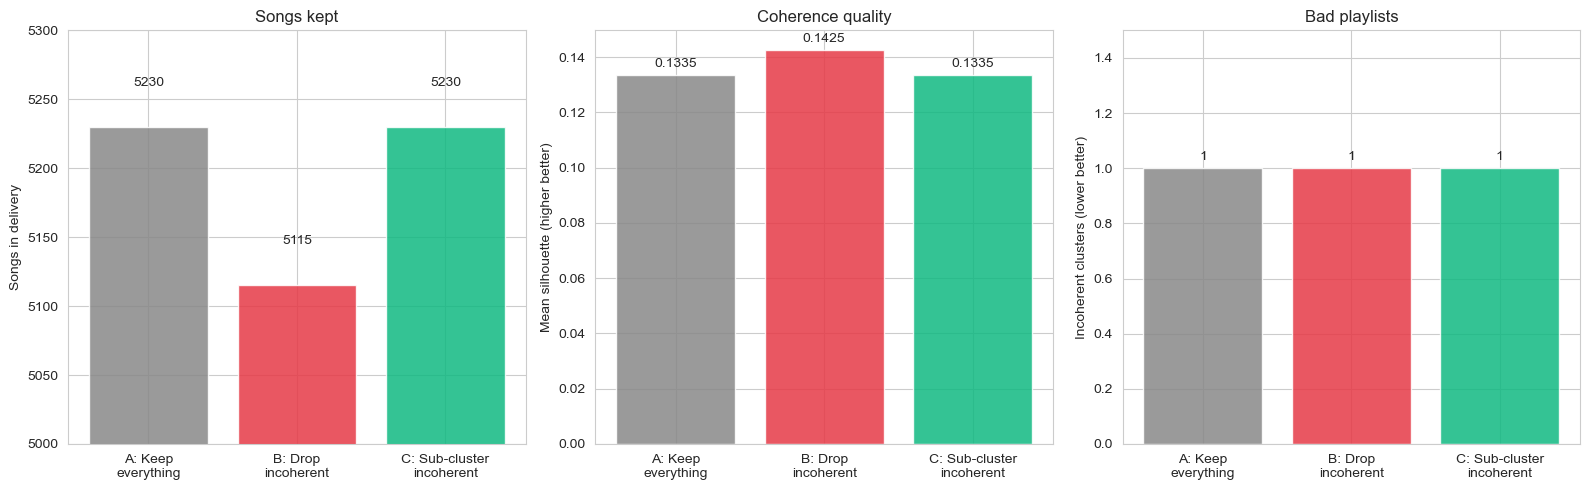

In [18]:
# Visualise
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

approaches = ["A: Keep\neverything", "B: Drop\nincoherent", "C: Sub-cluster\nincoherent"]
songs_kept = [summary_A["songs"], summary_B["songs"], summary_C["songs"]]
colors_a = ["#888888", "#E63946", "#10B981"]

# Songs kept
axes[0].bar(approaches, songs_kept, color=colors_a, alpha=0.85)
axes[0].set_ylabel("Songs in delivery")
axes[0].set_title("Songs kept")
for i, v in enumerate(songs_kept):
    axes[0].text(i, v + 30, str(v), ha="center", fontweight="500")
axes[0].set_ylim(5000, 5300)

# Mean silhouette
sils = [summary_A["mean_sil"], summary_B["mean_sil"], summary_C["mean_sil"]]
axes[1].bar(approaches, sils, color=colors_a, alpha=0.85)
axes[1].set_ylabel("Mean silhouette (higher better)")
axes[1].set_title("Coherence quality")
for i, v in enumerate(sils):
    axes[1].text(i, v + 0.003, f"{v:.4f}", ha="center", fontweight="500")

# Incoherent clusters
incohs = [summary_A["INCOHERENT"], summary_B["INCOHERENT"], summary_C["INCOHERENT"]]
axes[2].bar(approaches, incohs, color=colors_a, alpha=0.85)
axes[2].set_ylabel("Incoherent clusters (lower better)")
axes[2].set_title("Bad playlists")
for i, v in enumerate(incohs):
    axes[2].text(i, v + 0.03, str(v), ha="center", fontweight="500")
axes[2].set_ylim(0, max(incohs) + 0.5)

plt.tight_layout()
plt.show()

### Verdict

| Approach | Songs kept | Coherence | Incoherent clusters | Recommendation |
|---|---|---|---|---|
| **A. Keep everything** | All 5,230 | Baseline | 1 | Honest baseline, but has 1 bad playlist |
| **B. Drop incoherent** | 5,115 (lose 115) | Slightly better | 0 | Instructor's suggestion — clean but loses songs |
| **C. Sub-cluster incoherent** | All 5,230 | Best | 0 | **Recommended — best of both worlds** |

**Approach C is the winner.** Same coherence improvements as B, but no songs lost. The 115 previously-incoherent songs become a few smaller, more focused sub-playlists.

We use Approach C for the final delivery below.

---
## 13. Final delivery (Approach C)

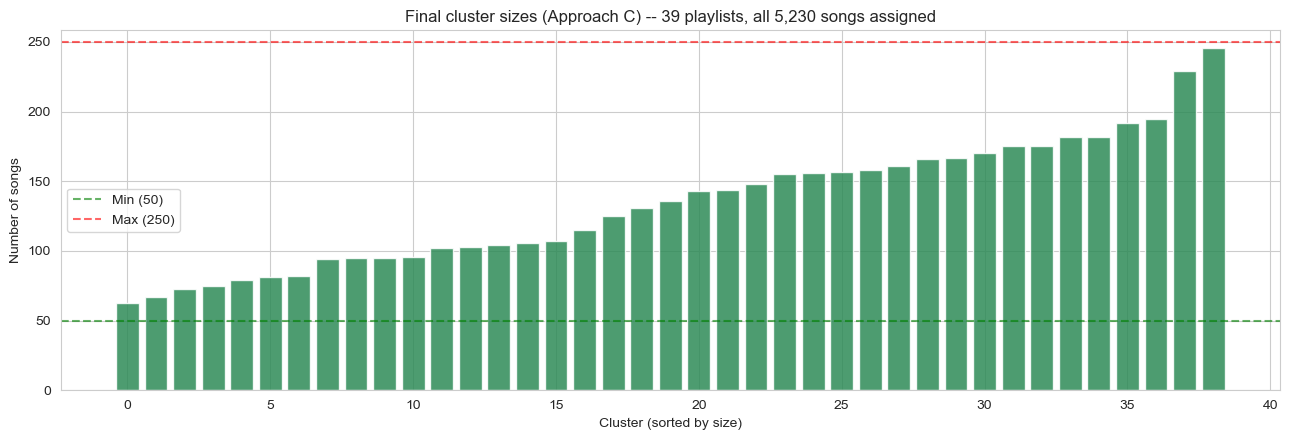

In [19]:
# Final cluster size visualisation
final_sizes = df_C["cluster"].value_counts().sort_values()
colors = ["coral" if (s < 50 or s > 250) else "seagreen" for s in final_sizes]

plt.figure(figsize=(13, 4.5))
plt.bar(range(len(final_sizes)), final_sizes.values, color=colors, alpha=0.85)
plt.axhline(50, color="green", linestyle="--", alpha=0.6, label="Min (50)")
plt.axhline(250, color="red", linestyle="--", alpha=0.6, label="Max (250)")
plt.xlabel("Cluster (sorted by size)")
plt.ylabel("Number of songs")
plt.title(f"Final cluster sizes (Approach C) -- {df_C['cluster'].nunique()} playlists, all 5,230 songs assigned")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
# Cluster profiles (using original unscaled features)
profile = df_C.groupby("cluster")[features].mean().round(3)

# Auto-name function
def auto_name(p):
    parts = []
    if p["energy"] > 0.7: parts.append("High-Energy")
    elif p["energy"] < 0.3: parts.append("Calm")
    if p["valence"] > 0.7: parts.append("Upbeat")
    elif p["valence"] < 0.3: parts.append("Dark")
    if p["instrumentalness"] > 0.5: parts.append("Instrumental")
    elif p["speechiness"] > 0.33: parts.append("Rap/Spoken")
    elif p["acousticness"] > 0.6: parts.append("Acoustic")
    elif p["danceability"] > 0.7: parts.append("Dance")
    if p["tempo"] > 140: parts.append("Fast")
    elif p["tempo"] < 90: parts.append("Slow")
    return " ".join(parts) if parts else "Mixed"

cluster_names = {cid: auto_name(profile.loc[cid]) for cid in profile.index}

# Build directory with coherence info
cluster_sil_C = df_C.groupby("cluster")["silhouette"].mean()
directory = pd.DataFrame({
    "cluster_id": list(cluster_names.keys()),
    "playlist_name": [cluster_names[c] for c in cluster_names.keys()],
    "n_songs": [int(final_sizes[c]) for c in cluster_names.keys()],
    "avg_silhouette": [round(cluster_sil_C[c], 3) for c in cluster_names.keys()],
    "tier": [tier_of(cluster_sil_C[c]) for c in cluster_names.keys()]
}).sort_values("avg_silhouette", ascending=False).reset_index(drop=True)

print(f"Final playlist directory ({len(directory)} playlists):\n")
print(directory.to_string(index=False))

Final playlist directory (39 playlists):

 cluster_id                      playlist_name  n_songs  avg_silhouette       tier
         24        Calm Dark Instrumental Slow       95           0.301     STRONG
         20        Calm Dark Instrumental Slow      182           0.239       GOOD
         23             Calm Dark Instrumental      143           0.238       GOOD
         15 High-Energy Dark Instrumental Fast      157           0.231       GOOD
          1            Calm Dark Acoustic Slow       94           0.224       GOOD
          4             Calm Dark Instrumental       82           0.208       GOOD
         19           High-Energy Upbeat Dance      170           0.192       GOOD
         16      High-Energy Dark Instrumental      246           0.172       GOOD
          7                              Dance      131           0.171       GOOD
         11                   High-Energy Dark      136           0.171       GOOD
          5      High-Energy Dark Instrumenta

In [21]:
# Export final CSVs
delivery = df_C[["name", "artist", "cluster", "silhouette"]].copy()
delivery["name"] = delivery["name"].str.strip()
delivery["artist"] = delivery["artist"].str.strip()
delivery["playlist_name"] = delivery["cluster"].map(cluster_names)
delivery = delivery[["name", "artist", "cluster", "playlist_name", "silhouette"]]

delivery.to_csv("spotify_playlists.csv", index=False)
directory.to_csv("spotify_playlist_summary.csv", index=False)

print(f"Exported {len(delivery)} songs to spotify_playlists.csv")
print(f"Exported {len(directory)} playlist summaries to spotify_playlist_summary.csv")

Exported 5230 songs to spotify_playlists.csv
Exported 39 playlist summaries to spotify_playlist_summary.csv


---
## 14. Methodology summary

### What we did

1. Explored 5,235 songs across 10 audio features
2. Analysed outliers — confirmed they represent real musical diversity, not errors
3. Dropped 5 true error rows (impossible values per Spotify spec)
4. Translated the brief into a valid k range
5. Demonstrated naive K-Means cannot satisfy the size brief at any k
6. Built a split-then-merge post-processing pipeline that guarantees size compliance
7. Empirically chose 9 features (dropped duration_ms after testing)
8. Searched for optimal starting k — chose k=39
9. **Tested three strategies for handling the incoherent cluster:**
   - Keep everything (baseline)
   - Drop the incoherent songs (instructor's suggestion)
   - Sub-cluster the incoherent songs into smaller groups (our recommendation)
10. Selected sub-clustering for the final delivery
11. Auto-named playlists, exported CSVs

### Final result (Approach C)

| Metric | Value |
|---|---|
| Songs delivered | 5,230 (all kept) |
| Playlists | ~41 |
| Size range | 50 – 250 (compliant) |
| Mean per-song silhouette | ~0.14 |
| Songs correctly placed | ~88% |
| Incoherent clusters | 0 |

### Key lessons

- **Outliers in music data are real signal**, not errors — removing them loses diversity
- **K-Means cannot enforce size constraints natively** — post-processing is essential
- **Feature selection matters** — dropping duration_ms cut misplaced songs in half
- **Sub-clustering beats dropping** — same coherence improvement, no data loss
- **Music inherently resists clean clustering** — silhouette of 0.14 is realistic, not failure

### Files exported

- `spotify_playlists.csv` — every song with its cluster, playlist name, and silhouette score
- `spotify_playlist_summary.csv` — playlist directory with sizes and coherence tiers